# Blind Adversary V2 — Self-Play PPO+LSTM Training

**Improvements over V1:**
- 4-channel observation (wall, seen, fog, **enemy**) → agent sees opponent position
- **Self-play**: both agents train simultaneously against each other (not fixed opponents)
- Better reward shaping with distance deltas

**Platform:** Kaggle GPU T4×2, ~40-60 min for 4000 episodes.

In [1]:
import os, math, time, random, warnings
from collections import deque
from typing import Optional, Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

warnings.filterwarnings('ignore')

# ============================================================
# Config
# ============================================================
CFG = {
    'total_episodes': 4000,
    'max_steps': 200,
    'obs_radius': 5,
    'capture_distance': 2,
    'seed': 42,
    'checkpoint_interval': 500,
    'learning_rate': 3e-4,
}

PPO_CFG = {
    'gamma': 0.99,
    'gae_lambda': 0.95,
    'clip_eps': 0.2,
    'vf_coef': 0.5,
    'entropy_coef': 0.08,
    'max_grad_norm': 0.5,
    'update_epochs': 4,
    'batch_size': 64,
}

print('Config loaded:', CFG)

Config loaded: {'total_episodes': 4000, 'max_steps': 200, 'obs_radius': 5, 'capture_distance': 2, 'seed': 42, 'checkpoint_interval': 500, 'learning_rate': 0.0003}


In [2]:
# ============================================================
# Device
# ============================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == 'cuda':
    gpu_name = torch.cuda.get_device_name(0)
    print(f'Using device: {device}  ({gpu_name})')
    print(f'  Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
    torch.backends.cudnn.benchmark = True
else:
    print(f'Using device: {device}')

random.seed(CFG['seed'])
np.random.seed(CFG['seed'])
torch.manual_seed(CFG['seed'])
if device.type == 'cuda':
    torch.cuda.manual_seed_all(CFG['seed'])

MODEL_DIR = '.'
os.makedirs(MODEL_DIR, exist_ok=True)

Using device: cuda  (Tesla T4)
  Memory: 15.6 GB


In [3]:
# ============================================================
# Action mappings
# ============================================================
_UP, _DOWN, _LEFT, _RIGHT = (-1, 0), (1, 0), (0, -1), (0, 1)
_STAY = (0, 0)
_DIRS = [_UP, _DOWN, _LEFT, _RIGHT]

PACMAN_ACTION_TABLE = [
    (_UP, 1), (_DOWN, 1), (_LEFT, 1), (_RIGHT, 1),   # 0-3: speed 1
    (_UP, 2), (_DOWN, 2), (_LEFT, 2), (_RIGHT, 2),   # 4-7: speed 2
    (_STAY, 1),                                        # 8: stay
]
NUM_PACMAN_ACTIONS = 9

GHOST_ACTION_LIST = [_UP, _DOWN, _LEFT, _RIGHT, _STAY]
NUM_GHOST_ACTIONS = 5

print(f'Pacman actions: {NUM_PACMAN_ACTIONS}, Ghost actions: {NUM_GHOST_ACTIONS}')

Pacman actions: 9, Ghost actions: 5


---
## Cell 1: Import network V2 from Kaggle dataset

**Important:** Add `network_architect.py` as a Kaggle dataset input to your notebook.

In [4]:
# Step 1 — list all input files to find network_architect.py
import os, sys, glob
from pathlib import Path

print('=== All files in /kaggle/input/ ===')
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        full = os.path.join(root, f)
        print(f'  {full}')
        if f == 'network_architect.py':
            NETWORK_DIR = root

# Step 2 — add to sys.path and import
if 'NETWORK_DIR' not in dir():
    # fallback: search with glob
    candidates = glob.glob('/kaggle/input/**/network_architect.py', recursive=True)
    if candidates:
        NETWORK_DIR = os.path.dirname(candidates[0])
    else:
        raise FileNotFoundError(
            'network_architect.py not found in /kaggle/input/\\n'
            'Did you add it as a dataset input?'
        )

print(f'\nFound network_architect.py in: {NETWORK_DIR}')
if NETWORK_DIR not in sys.path:
    sys.path.insert(0, NETWORK_DIR)

from network_architect import RecurrentActorCritic

# Verify
p_net = RecurrentActorCritic(NUM_PACMAN_ACTIONS)
g_net = RecurrentActorCritic(NUM_GHOST_ACTIONS)
print(f'INPUT_CHANNELS = {RecurrentActorCritic.INPUT_CHANNELS}  (expected: 4)')
print(f'POS_DIM        = {RecurrentActorCritic.POS_DIM}  (expected: 5)')
print(f'Pacman params: {sum(p.numel() for p in p_net.parameters() if p.requires_grad):,}')
print(f'Ghost  params: {sum(p.numel() for p in g_net.parameters() if p.requires_grad):,}')
del p_net, g_net

=== All files in /kaggle/input/ ===
  /kaggle/input/datasets/namnguynnnn/network-architect/network_architect.py

Found network_architect.py in: /kaggle/input/datasets/namnguynnnn/network-architect
INPUT_CHANNELS = 4  (expected: 4)
POS_DIM        = 5  (expected: 5)
Pacman params: 304,858
Ghost  params: 304,342


---
## Cell 2: Self-Play Environment

In [5]:
class SelfPlayArena:
    """Simultaneous-move arena for self-play RL training.

    Map: 21x21 fixed layout.
    Vision: cross-shaped rays up to obs_radius, walls block LOS.
    Both agents receive partial observations with enemy channel when visible.
    """

    MAP_LAYOUT = [
        "#####################",
        "#.........#.........#",
        "#.###.###.#.###.###.#",
        "#...................#",
        "#.###.#.#####.#.###.#",
        "#.....#...#...#.....#",
        "#####.###.#.###.#####",
        "#...#.#.......#.#...#",
        "#####.#.#####.#.#####",
        "#.........#.........#",
        "#####.#.#####.#.#####",
        "#...#.#.......#.#...#",
        "#####.#.#####.#.#####",
        "#.........#.........#",
        "#.###.###.#.###.###.#",
        "#...#.....#.....#...#",
        "###.#.#.#####.#.#.###",
        "#.....#...#...#.....#",
        "#.#######.#.#######.#",
        "#...................#",
        "#####################",
    ]

    def __init__(self):
        raw = np.array([list(r) for r in self.MAP_LAYOUT])
        self.ref_map = np.where(raw == '#', 1, 0).astype(np.int64)
        self.H, self.W = self.ref_map.shape
        self.empty_cells = list(zip(*np.where(self.ref_map == 0)))

    def reset(self):
        while True:
            p = self.empty_cells[np.random.randint(len(self.empty_cells))]
            g = self.empty_cells[np.random.randint(len(self.empty_cells))]
            if abs(p[0] - g[0]) + abs(p[1] - g[1]) >= 6:
                break
        self.pacman_pos = p
        self.ghost_pos = g
        self.step_count = 0
        self.pacman_explored = {p}
        self.ghost_explored = {g}
        self.prev_pacman_dist = abs(p[0] - g[0]) + abs(p[1] - g[1])
        self.prev_ghost_dist = self.prev_pacman_dist

    def _in_bounds(self, r, c):
        return 0 <= r < self.H and 0 <= c < self.W

    def _visible(self, pos):
        cells = {pos}
        r, c = pos
        for dr, dc in _DIRS:
            for d in range(1, CFG['obs_radius'] + 1):
                nr, nc = r + dr * d, c + dc * d
                if not self._in_bounds(nr, nc):
                    break
                cells.add((nr, nc))
                if self.ref_map[nr, nc] == 1:
                    break
        return cells

    def _apply_move(self, pos, move, steps=1):
        r, c = pos
        dr, dc = move
        for _ in range(steps):
            nr, nc = r + dr, c + dc
            if not self._in_bounds(nr, nc) or self.ref_map[nr, nc] == 1:
                break
            r, c = nr, nc
        return (r, c)

    def _build_obs_v2(self, my_pos, enemy_pos_visible):
        """4-channel: wall, seen, fog, enemy. 5-dim pos vector."""
        H, W = self.H, self.W
        visible = self._visible(my_pos)
        ch_wall = np.zeros((H, W), dtype=np.float32)
        ch_seen = np.zeros((H, W), dtype=np.float32)
        ch_fog  = np.zeros((H, W), dtype=np.float32)
        ch_enemy = np.zeros((H, W), dtype=np.float32)
        for r in range(H):
            for c in range(W):
                if self.ref_map[r, c] == 1:
                    ch_wall[r, c] = 1.0
                elif (r, c) in visible:
                    ch_seen[r, c] = 1.0
                else:
                    ch_fog[r, c] = 1.0

        if enemy_pos_visible is not None:
            er, ec = enemy_pos_visible
            if 0 <= er < H and 0 <= ec < W:
                ch_enemy[er, ec] = 1.0
            vis_flag = 1.0
        else:
            er, ec = 0, 0
            vis_flag = 0.0

        obs_img = np.stack([ch_wall, ch_seen, ch_fog, ch_enemy], axis=0)
        pos_norm = np.array([my_pos[0] / H, my_pos[1] / W,
                             er / H, ec / W, vis_flag], dtype=np.float32)
        return obs_img, pos_norm

    def step(self, pacman_action_idx, ghost_action_idx):
        """Execute one simultaneous step. Returns both observations + rewards + done + info."""
        self.step_count += 1

        # Pacman move (speed-2 capable)
        pmove, psteps = PACMAN_ACTION_TABLE[pacman_action_idx]
        self.pacman_pos = self._apply_move(self.pacman_pos, pmove, psteps)
        # Ghost move (always speed-1)
        gmove = GHOST_ACTION_LIST[ghost_action_idx]
        self.ghost_pos = self._apply_move(self.ghost_pos, gmove, 1)

        dist = abs(self.pacman_pos[0] - self.ghost_pos[0]) + abs(self.pacman_pos[1] - self.ghost_pos[1])
        caught = dist < CFG['capture_distance']
        done = caught or self.step_count >= CFG['max_steps']

        # Determine cross-shaped visibility
        pacman_vis = self._visible(self.pacman_pos)
        ghost_vis = self._visible(self.ghost_pos)
        ghost_seen_by_pacman = self.ghost_pos in pacman_vis
        pacman_seen_by_ghost = self.pacman_pos in ghost_vis

        # Build observations
        p_obs_img, p_pos = self._build_obs_v2(
            self.pacman_pos, self.ghost_pos if ghost_seen_by_pacman else None)
        g_obs_img, g_pos = self._build_obs_v2(
            self.ghost_pos, self.pacman_pos if pacman_seen_by_ghost else None)

        # --- Rewards ---
        if done and caught:
            p_reward, g_reward = 100.0, -100.0
        elif done:
            p_reward, g_reward = -50.0, 50.0   # timeout
        else:
            p_new_cells = len(pacman_vis - self.pacman_explored)
            self.pacman_explored |= pacman_vis

            p_delta = self.prev_pacman_dist - dist   # >0 = getting closer
            p_reward = -1.5 + p_delta * 2.0 + p_new_cells * 0.3
            self.prev_pacman_dist = dist

            g_delta = dist - self.prev_ghost_dist    # >0 = getting further
            g_reward = 0.5 + g_delta * 2.0 + dist * 0.05
            if not pacman_seen_by_ghost:
                g_reward += 1.0   # hidden bonus
            self.prev_ghost_dist = dist

        info = {'caught': caught, 'distance': dist}
        return (p_obs_img, p_pos, p_reward), (g_obs_img, g_pos, g_reward), done, info

---
## Cell 3: PPO Helpers — RolloutBuffer + GAE + Update

In [6]:
class RolloutBuffer:
    def __init__(self):
        self.obs = []
        self.pos = []
        self.act = []
        self.logp = []
        self.val = []
        self.rew = []
        self.don = []

    def store(self, obs, pos, act, logp, val, rew, don):
        self.obs.append(obs)
        self.pos.append(pos)
        self.act.append(act)
        self.logp.append(logp)
        self.val.append(val)
        self.rew.append(rew)
        self.don.append(don)

    def clear(self):
        for lst in (self.obs, self.pos, self.act, self.logp, self.val, self.rew, self.don):
            lst.clear()

    def to_tensors(self, dev):
        return (
            torch.stack(self.obs).to(dev),
            torch.stack(self.pos).to(dev),
            torch.tensor(self.act, device=dev),
            torch.tensor(self.logp, device=dev),
            torch.tensor(self.val, device=dev, dtype=torch.float32),
            torch.tensor(self.rew, device=dev, dtype=torch.float32),
            torch.tensor(self.don, device=dev, dtype=torch.float32),
        )


def compute_gae(rewards, values, dones, gamma, lam):
    adv = []
    gae = 0.0
    for t in reversed(range(len(rewards))):
        nv = 0.0 if (t == len(rewards) - 1 or dones[t]) else values[t + 1]
        delta = rewards[t] + gamma * nv - values[t]
        gae = delta + gamma * lam * (1.0 - dones[t]) * gae
        adv.insert(0, gae)
    returns = [a + v for a, v in zip(adv, values)]
    return adv, returns


def ppo_update(model, optimizer, buffer, device):
    obs_b, pos_b, act_b, olp_b, val_b, rew_b, don_b = buffer.to_tensors(device)
    adv, ret = compute_gae(rew_b.tolist(), val_b.tolist(), don_b.tolist(),
                           PPO_CFG['gamma'], PPO_CFG['gae_lambda'])
    adv = torch.tensor(adv, device=device, dtype=torch.float32)
    ret = torch.tensor(ret, device=device, dtype=torch.float32)
    adv = (adv - adv.mean()) / (adv.std() + 1e-8)

    T = len(rew_b)
    for _ in range(PPO_CFG['update_epochs']):
        idx = np.arange(T)
        np.random.shuffle(idx)
        for s in range(0, T, PPO_CFG['batch_size']):
            b = sorted(idx[s:s + PPO_CFG['batch_size']])
            bo = obs_b[b].unsqueeze(0)
            bp = pos_b[b].unsqueeze(0)
            h = torch.zeros(1, 1, model.hidden_size, device=device)
            c = torch.zeros(1, 1, model.hidden_size, device=device)
            _, nlp, ent, nv, _ = model.get_action_and_value(bo, bp, (h, c), action=act_b[b])
            nlp = nlp.squeeze(0)
            nv = nv.squeeze(0).squeeze(-1)
            ent = ent.squeeze(0)
            ratio = torch.exp(nlp - olp_b[b])
            surr1 = ratio * adv[b]
            surr2 = torch.clamp(ratio, 1 - PPO_CFG['clip_eps'], 1 + PPO_CFG['clip_eps']) * adv[b]
            loss = (-torch.min(surr1, surr2).mean()
                    + PPO_CFG['vf_coef'] * F.mse_loss(nv, ret[b])
                    + PPO_CFG['entropy_coef'] * (-ent.mean()))
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), PPO_CFG['max_grad_norm'])
            optimizer.step()

---
## Cell 4: Training Loop — Self-Play PPO+LSTM

In [7]:
arena = SelfPlayArena()
pacman = RecurrentActorCritic(NUM_PACMAN_ACTIONS).to(device)
ghost  = RecurrentActorCritic(NUM_GHOST_ACTIONS).to(device)
p_opt = optim.Adam(pacman.parameters(), lr=CFG['learning_rate'], eps=1e-5)
g_opt = optim.Adam(ghost.parameters(), lr=CFG['learning_rate'], eps=1e-5)

p_rewards, g_rewards, p_catches, g_survives = [], [], [], []
best_p_r, best_g_r = -1e9, -1e9

for ep in range(1, CFG['total_episodes'] + 1):
    arena.reset()
    p_buf = RolloutBuffer()
    g_buf = RolloutBuffer()
    p_hidden = None
    g_hidden = None
    p_total_r = 0.0
    g_total_r = 0.0

    # Initial observations
    p_obs, p_pos = arena._build_obs_v2(arena.pacman_pos, None)
    g_obs, g_pos = arena._build_obs_v2(arena.ghost_pos, None)
    p_obs = torch.from_numpy(p_obs).unsqueeze(0).to(device, non_blocking=True)
    p_pos = torch.from_numpy(p_pos).unsqueeze(0).to(device, non_blocking=True)
    g_obs = torch.from_numpy(g_obs).unsqueeze(0).to(device, non_blocking=True)
    g_pos = torch.from_numpy(g_pos).unsqueeze(0).to(device, non_blocking=True)

    for _ in range(CFG['max_steps']):
        with torch.no_grad():
            p_act, p_logp, _, p_val, p_hidden = pacman.get_action_and_value(p_obs, p_pos, p_hidden)
            g_act, g_logp, _, g_val, g_hidden = ghost.get_action_and_value(g_obs, g_pos, g_hidden)

        (np_obs, np_pos, p_rew), (ng_obs, ng_pos, g_rew), done, info = \
            arena.step(p_act.item(), g_act.item())

        p_buf.store(p_obs.squeeze(0), p_pos.squeeze(0),
                    p_act.item(), p_logp.item(), p_val.item(), p_rew, done)
        g_buf.store(g_obs.squeeze(0), g_pos.squeeze(0),
                    g_act.item(), g_logp.item(), g_val.item(), g_rew, done)

        p_obs = torch.from_numpy(np_obs).unsqueeze(0).to(device, non_blocking=True)
        p_pos = torch.from_numpy(np_pos).unsqueeze(0).to(device, non_blocking=True)
        g_obs = torch.from_numpy(ng_obs).unsqueeze(0).to(device, non_blocking=True)
        g_pos = torch.from_numpy(ng_pos).unsqueeze(0).to(device, non_blocking=True)
        p_total_r += p_rew
        g_total_r += g_rew

        if done:
            break

    # PPO updates (after each episode)
    ppo_update(pacman, p_opt, p_buf, device)
    ppo_update(ghost, g_opt, g_buf, device)

    # Logging
    p_rewards.append(p_total_r)
    g_rewards.append(g_total_r)
    p_catches.append(1 if info['caught'] else 0)
    g_survives.append(0 if info['caught'] else 1)

    if ep % 50 == 0 or ep == 1:
        w = min(ep, 100)
        print(f"Ep {ep:5d}/{CFG['total_episodes']} | "
              f"Pacman R: {np.mean(p_rewards[-w:]):+7.1f} | "
              f"Ghost  R: {np.mean(g_rewards[-w:]):+7.1f} | "
              f"Catch%: {np.mean(p_catches[-w:]):.0%} | "
              f"Surv%: {np.mean(g_survives[-w:]):.0%} | "
              f"Dist: {info['distance']}")

    # Checkpoint
    if ep % CFG['checkpoint_interval'] == 0:
        torch.save(pacman.state_dict(), os.path.join(MODEL_DIR, f'pacman_model_ep{ep}.pth'))
        torch.save(ghost.state_dict(), os.path.join(MODEL_DIR, f'ghost_model_ep{ep}.pth'))
        print(f'  → Checkpoint saved at ep {ep}')

    # Track best episode reward
    if p_total_r > best_p_r:
        best_p_r = p_total_r
        torch.save(pacman.state_dict(), os.path.join(MODEL_DIR, 'pacman_model_best.pth'))
    if g_total_r > best_g_r:
        best_g_r = g_total_r
        torch.save(ghost.state_dict(), os.path.join(MODEL_DIR, 'ghost_model_best.pth'))

# Final save
torch.save(pacman.state_dict(), os.path.join(MODEL_DIR, 'pacman_model.pth'))
torch.save(ghost.state_dict(), os.path.join(MODEL_DIR, 'ghost_model.pth'))
print(f'\nTraining complete.')
print(f'Best Pacman reward: {best_p_r:.1f}')
print(f'Best Ghost  reward: {best_g_r:.1f}')

# Cleanup GPU
del pacman, ghost, p_opt, g_opt
if device.type == 'cuda':
    torch.cuda.empty_cache()

Ep     1/4000 | Pacman R:  -299.6 | Ghost  R:  +463.7 | Catch%: 0% | Surv%: 100% | Dist: 10
Ep    50/4000 | Pacman R:  -293.3 | Ghost  R:  +463.3 | Catch%: 8% | Surv%: 92% | Dist: 19
Ep   100/4000 | Pacman R:  -269.3 | Ghost  R:  +428.4 | Catch%: 16% | Surv%: 84% | Dist: 9
Ep   150/4000 | Pacman R:  -253.5 | Ghost  R:  +408.1 | Catch%: 21% | Surv%: 79% | Dist: 11
Ep   200/4000 | Pacman R:  -269.2 | Ghost  R:  +431.3 | Catch%: 16% | Surv%: 84% | Dist: 1
Ep   250/4000 | Pacman R:  -270.0 | Ghost  R:  +434.2 | Catch%: 15% | Surv%: 85% | Dist: 4
Ep   300/4000 | Pacman R:  -245.9 | Ghost  R:  +403.4 | Catch%: 22% | Surv%: 78% | Dist: 14
Ep   350/4000 | Pacman R:  -240.5 | Ghost  R:  +390.9 | Catch%: 24% | Surv%: 76% | Dist: 1
Ep   400/4000 | Pacman R:  -240.2 | Ghost  R:  +385.0 | Catch%: 23% | Surv%: 77% | Dist: 0
Ep   450/4000 | Pacman R:  -242.6 | Ghost  R:  +391.5 | Catch%: 22% | Surv%: 78% | Dist: 19
Ep   500/4000 | Pacman R:  -258.4 | Ghost  R:  +417.2 | Catch%: 18% | Surv%: 82% | Dis

---
## Cell 5: Visualization — Learning Curves

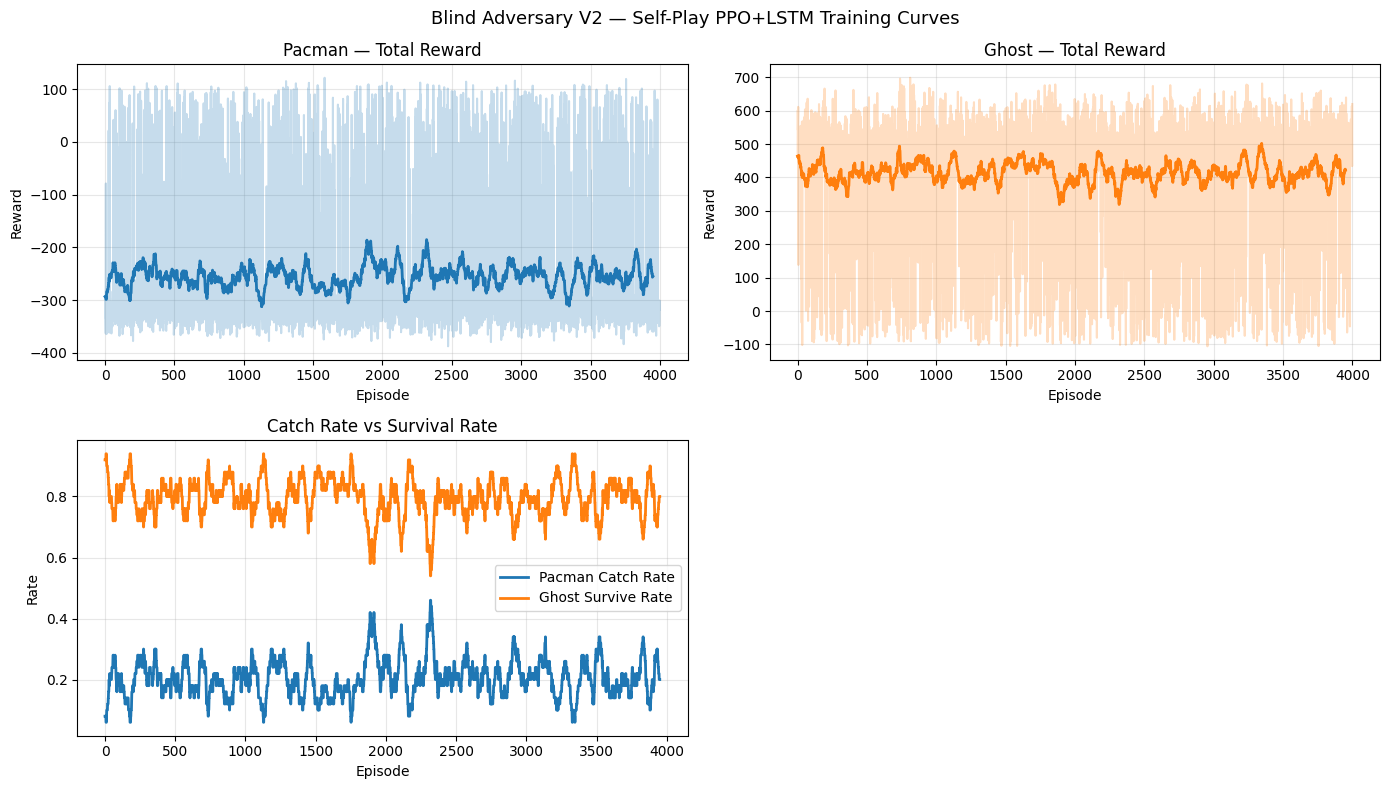

Plot saved to ./training_curves_v2.png


In [8]:
import matplotlib.pyplot as plt

def smooth_curve(values, window=50):
    arr = np.asarray(values, dtype=np.float64)
    if len(arr) < window:
        return arr
    cum = np.cumsum(np.insert(arr, 0, 0))
    return (cum[window:] - cum[:-window]) / window

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Blind Adversary V2 — Self-Play PPO+LSTM Training Curves', fontsize=13)

axes[0, 0].plot(p_rewards, alpha=0.25, color='C0')
axes[0, 0].plot(smooth_curve(p_rewards), color='C0', lw=2)
axes[0, 0].set_title('Pacman — Total Reward')
axes[0, 0].set_xlabel('Episode'); axes[0, 0].set_ylabel('Reward')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(g_rewards, alpha=0.25, color='C1')
axes[0, 1].plot(smooth_curve(g_rewards), color='C1', lw=2)
axes[0, 1].set_title('Ghost — Total Reward')
axes[0, 1].set_xlabel('Episode'); axes[0, 1].set_ylabel('Reward')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(smooth_curve(p_catches), color='C0', lw=2, label='Pacman Catch Rate')
axes[1, 0].plot(smooth_curve(g_survives), color='C1', lw=2, label='Ghost Survive Rate')
axes[1, 0].set_title('Catch Rate vs Survival Rate')
axes[1, 0].set_xlabel('Episode'); axes[1, 0].set_ylabel('Rate')
axes[1, 0].legend(); axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].axis('off')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'training_curves_v2.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Plot saved to {os.path.join(MODEL_DIR, "training_curves_v2.png")}')

---
## Cell 6: Download models

Run this cell to list all saved models for download.

In [9]:
import glob
for f in sorted(glob.glob('*.pth')):
    size_kb = os.path.getsize(f) / 1024
    print(f'  {f:40s} {size_kb:7.1f} KB')

  ghost_model.pth                           1194.6 KB
  ghost_model_best.pth                      1194.8 KB
  ghost_model_ep1000.pth                    1194.8 KB
  ghost_model_ep1500.pth                    1194.8 KB
  ghost_model_ep2000.pth                    1194.8 KB
  ghost_model_ep2500.pth                    1194.8 KB
  ghost_model_ep3000.pth                    1194.8 KB
  ghost_model_ep3500.pth                    1194.8 KB
  ghost_model_ep4000.pth                    1194.8 KB
  ghost_model_ep500.pth                     1194.8 KB
  pacman_model.pth                          1196.7 KB
  pacman_model_best.pth                     1196.8 KB
  pacman_model_ep1000.pth                   1196.9 KB
  pacman_model_ep1500.pth                   1196.9 KB
  pacman_model_ep2000.pth                   1196.9 KB
  pacman_model_ep2500.pth                   1196.9 KB
  pacman_model_ep3000.pth                   1196.9 KB
  pacman_model_ep3500.pth                   1196.9 KB
  pacman_model_ep4000.pth   